<a href="https://colab.research.google.com/github/adhvaitaganesh/data-visualisation/blob/main/AIs_impact_on_Jobs.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# IMPORTANT: RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES,
# THEN FEEL FREE TO DELETE THIS CELL.
# NOTE: THIS NOTEBOOK ENVIRONMENT DIFFERS FROM KAGGLE'S PYTHON
# ENVIRONMENT SO THERE MAY BE MISSING LIBRARIES USED BY YOUR
# NOTEBOOK.
import kagglehub
manavgupta92_from_data_entry_to_ceo_the_ai_job_threat_index_path = kagglehub.dataset_download('manavgupta92/from-data-entry-to-ceo-the-ai-job-threat-index')

print('Data source import complete.')


Data source import complete.


# Addressing the Impact of AI and Automation on Job Displacement                                                                                                                                                                             
![image.png](attachment:74a1a198-cc78-4287-87a6-5fe86a5bf50c.png)



### Scenario

Let's delve into our current society to explore how AI and automation are potentially replacing human jobs or are more subseptible to being replaced by AI. Our report aims to assess the extent to which various roles within our society plants are susceptible to being replaced by AI technologies, and the subsequent implications for the workforce.

# 1) Ask

### Identify the Business Task

In our rapidly evolving society, the integration of AI and automation is significantly altering the landscape of various industries and job roles. This transformative shift brings forth a pressing issue that demands our attention: the potential displacement of human jobs by AI technologies.

The problem at hand is multifaceted. On one hand, we observe a steady advancement in AI capabilities that enable machines to perform tasks traditionally carried out by humans. Routine, repetitive, and rule-based functions are increasingly being automated, leading to increased efficiency and reduced operational costs for businesses. However, on the other hand, this automation also gives rise to concerns about the potential displacement of human workers from these roles.

## Business Task

To discover which are the most and least affected jobs by AI and find what makes them susceptible to AI in the first place.

# 2) Prepare

#### a) Data Used

I Kaggle dataset [From Data Entry to CEO: The AI Job Threat Index](https://www.kaggle.com/datasets/manavgupta92/from-data-entry-to-ceo-the-ai-job-threat-index) to conduct the statistical analysisin this ocation, the data was uploaded by TENSOR BOY.

#### b) Accessibility and Usage of Data

The dataset pertaining to accessibility and data usage was made available by TENSOR BOY on Kaggle.com. It is published under the CC0: Public Domain Creative Common License, as specified in the license [here](https://creativecommons.org/publicdomain/zero/1.0/). The author obtained the data through "he data has been sourced primarily from leading AI tools websites that provide insights into job analytics, AI implementations in the corporate world, and the broader impact of AI on the job market. By combining data from multiple trusted platforms, the dataset offers a holistic view, capturing both the depth and breadth of the evolving job landscape in the AI era."

#### c) Data Summary

Contained within this file is a comprehensive dataset examining the interplay between job roles and the pervasive influence of artificial intelligence (AI). Each entry meticulously categorizes job titles, shedding light on AI's potential impact, the workload distribution between human tasks and AI models, and the domain to which each job belongs.

- Job Titles: Names of different job roles across various industries.

- AI Impact: Percentage representation of AI's influence on each respective job title. This value indicates the extent to which AI technology has impacted or transformed the job role.

- Tasks: Numerical count of human-performed tasks associated with each job title. This column provides an insight into the range and complexity of tasks performed by professionals in each role.

- AI Models: Count of AI models or systems implemented or associated with each job title. This column indicates the extent to which AI technologies have been integrated into the workflow of each job role.

- AI Workload Ratio: A computed ratio that represents the workload distribution between tasks performed by humans and tasks managed by AI models. This ratio helps to understand the balance between human labor and AI automation within each job role.

- Domain: The broader category or industry to which each job title belongs. This column provides context about the specific field or sector in which each job role operates.

# 3) Process

The data processing stage for the tables used involved several steps to clean and prepare the data for analysis. The following summary outlines the key stages of the process:

a) File Format: The tables were initially downloaded in CSV file format, which is a commonly used format for tabular data and then uploaded into Kaggle for cleaning using Python.

### I- Importing Libraries

Import the libraries that we will be using to conduct cleaning and analysis.


In [ ]:
#Importing packages we will use in this project

import pandas as pd
import numpy as np
import seaborn as sns

import matplotlib.pyplot as plt
import matplotlib.mlab as mlab
import matplotlib
plt.style.use('ggplot')
from matplotlib.pyplot import figure

%matplotlib inline
matplotlib.rcParams['figure.figsize'] = (12,8)

pd.options.mode.chained_assignment = None

### II- We load the csv data to use in analysis

When loading the data using pandas function .readcsv() we store it in a variable df (Data frame).

In [ ]:
#Loading data

df = pd.read_csv('/kaggle/input/from-data-entry-to-ceo-the-ai-job-threat-index/My_Data.csv')


### III- Understand data

We employ the functions df.info(), df.head(), and df.describe() in our initial exploration of the dataset. These functions serve various purposes: df.info() provides comprehensive information about the dataset, including the presence of null values, data types, and column names. Following this, we utilize df.head() to visualize the first five rows of the dataset, offering us an initial glimpse into the data's structure.

In [ ]:
#Get information about our dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4706 entries, 0 to 4705
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Job titiles        4706 non-null   object 
 1   AI Impact          4706 non-null   object 
 2   Tasks              4706 non-null   int64  
 3   AI models          4706 non-null   int64  
 4   AI_Workload_Ratio  4706 non-null   float64
 5   Domain             4706 non-null   object 
dtypes: float64(1), int64(2), object(3)
memory usage: 220.7+ KB


In [ ]:
#print first 5 rows of data
print( df.head())


              Job titiles AI Impact  Tasks  AI models  AI_Workload_Ratio  \
0  Communications Manager       98%    365       2546           0.143362   
1          Data Collector       95%    299       2148           0.139199   
2              Data Entry       95%    325       2278           0.142669   
3              Mail Clerk       95%    193       1366           0.141288   
4      Compliance Officer       92%    194       1369           0.141709   

                      Domain  
0         Communication & PR  
1                  Data & IT  
2  Administrative & Clerical  
3      Leadership & Strategy  
4       Medical & Healthcare  


### IV- Removing Infinite values

We need to transform those values to something else to continue with investigation, with the following code we transform them into nan or Not a Number values so they dont interfere with investigation.

In [ ]:
#The column AI_Workload_Ratio has some Infinite values that had to be removed for analysis

df['AI_Workload_Ratio'].replace([np.inf, -np.inf], np.nan, inplace=True)


/tmp/ipython-input-8-57072623.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['AI_Workload_Ratio'].replace([np.inf, -np.inf], np.nan, inplace=True)


### V- Verifying there is no missing data

When run the following code to confirm that there is no missing values in any of the columns of our dataset.

In [ ]:
#check for missing data
for col in df.columns:
    pct_missing = np.mean(df[col].isnull())
    print('{} - {}%'.format(col, round(pct_missing*100)))

Job titiles - 0%
AI Impact - 0%
Tasks - 0%
AI models - 0%
AI_Workload_Ratio - 0%
Domain - 0%


### VI- Rename columns and drop duplicates

We rename the column called "Job Titiles" to "Job Titles", it is important to have accurate column names when working with data since it can avoid problems when analyzing. After this we run the "column_names" variable to verify that the column names are correct in our dataset.

We use the .drop_duplicates() function to drop any duplicate values that might be in our dataset, after verifying number of rows there didnt seem to be any duplicates in our data.

In [ ]:
#Renaming the Column Job Titiles to Job Titles

df.rename(columns ={'Job titiles' : 'Job Titles'}, inplace = True  )

In [ ]:
#We create a variable to store our column names in case they need to be reminded of

column_names = df.columns.tolist()

print("Column names:", column_names)

Column names: ['Job Titles', 'AI Impact', 'Tasks', 'AI models', 'AI_Workload_Ratio', 'Domain']


In [ ]:
#Drop duplicates

df.drop_duplicates()

,Job Titles,AI Impact,Tasks,AI models,AI_Workload_Ratio,Domain
0,Communications Manager,98%,365,2546,0.143362,Communication & PR
1,Data Collector,95%,299,2148,0.139199,Data & IT
2,Data Entry,95%,325,2278,0.142669,Administrative & Clerical
3,Mail Clerk,95%,193,1366,0.141288,Leadership & Strategy
4,Compliance Officer,92%,194,1369,0.141709,Medical & Healthcare
...,...,...,...,...,...,...
4701,Singer,5%,686,2798,0.245175,Data & IT
4702,Airport,5%,556,2206,0.252040,Administrative & Clerical
4703,Director,5%,1316,4695,0.280298,Leadership & Strategy
4704,Nurse,5%,710,2594,0.273709,Medical & Healthcare


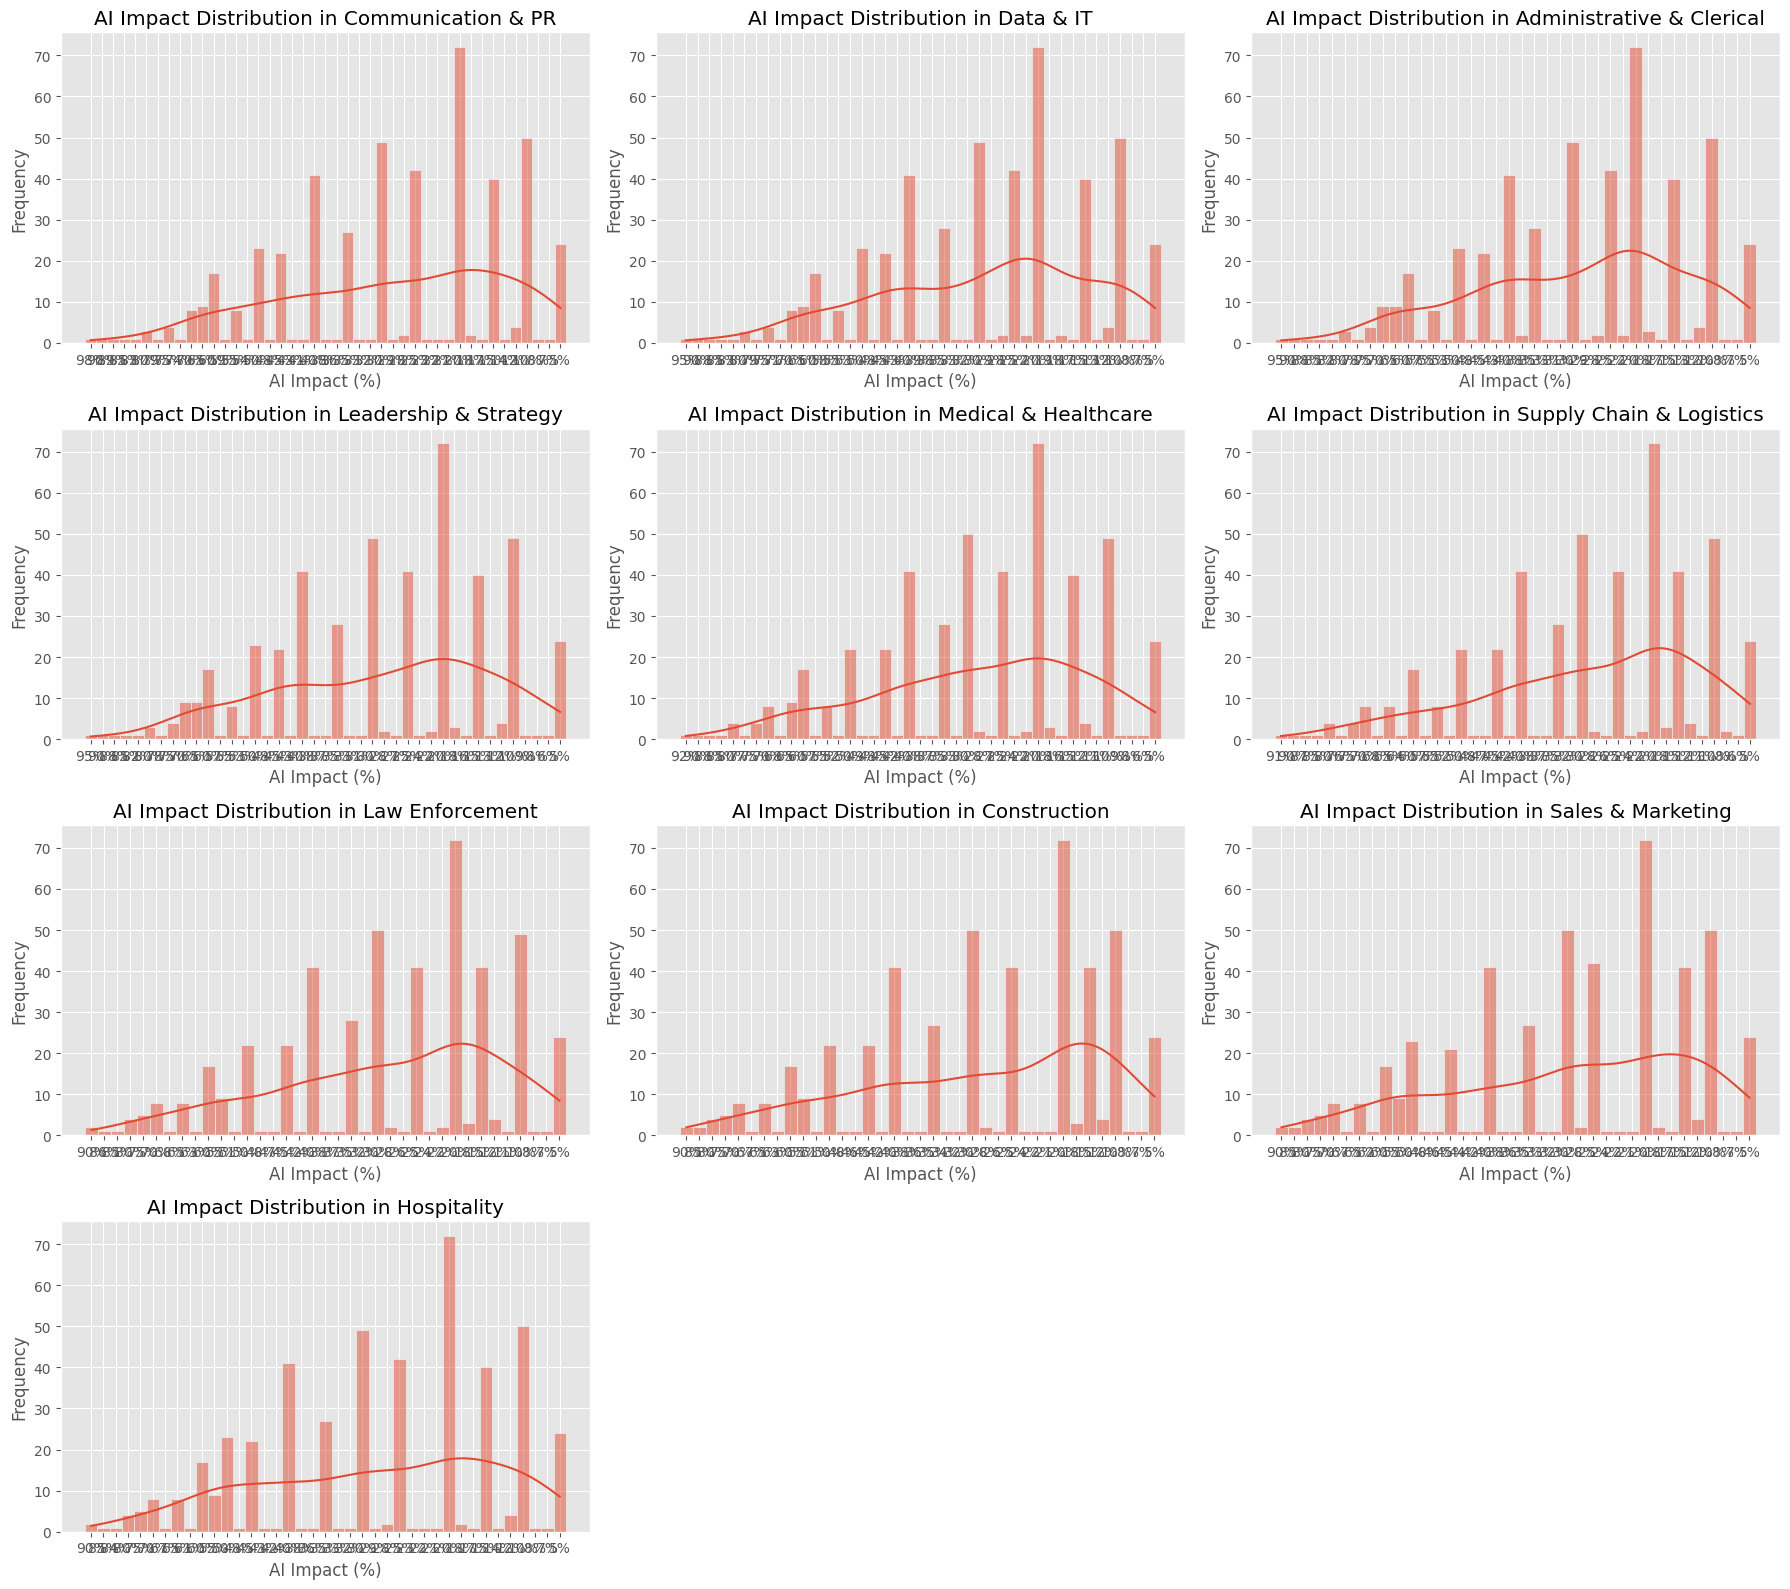

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Get unique domains
unique_domains = df['Domain'].unique()

# Set up the plot layout (optional, depending on the number of domains)
# You might want to adjust the number of columns and rows based on your needs
n_cols = 3  # Number of columns in the plot grid
n_rows = (len(unique_domains) + n_cols - 1) // n_cols # Calculate number of rows

plt.figure(figsize=(n_cols * 6, n_rows * 4)) # Adjust figure size as needed

# Iterate through domains and plot histograms
for i, domain in enumerate(unique_domains):
    plt.subplot(n_rows, n_cols, i + 1) # Create a subplot for each domain
    domain_df = df[df['Domain'] == domain]
    sns.histplot(data=domain_df, x='AI Impact', kde=True) # Use seaborn for a nice histogram with KDE
    plt.title(f'AI Impact Distribution in {domain}')
    plt.xlabel('AI Impact (%)')
    plt.ylabel('Frequency')

plt.tight_layout() # Adjust layout to prevent overlapping titles/labels
plt.show()

/tmp/ipython-input-14-3200305671.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x='AI Impact', y='Domain', data=df, palette='viridis')


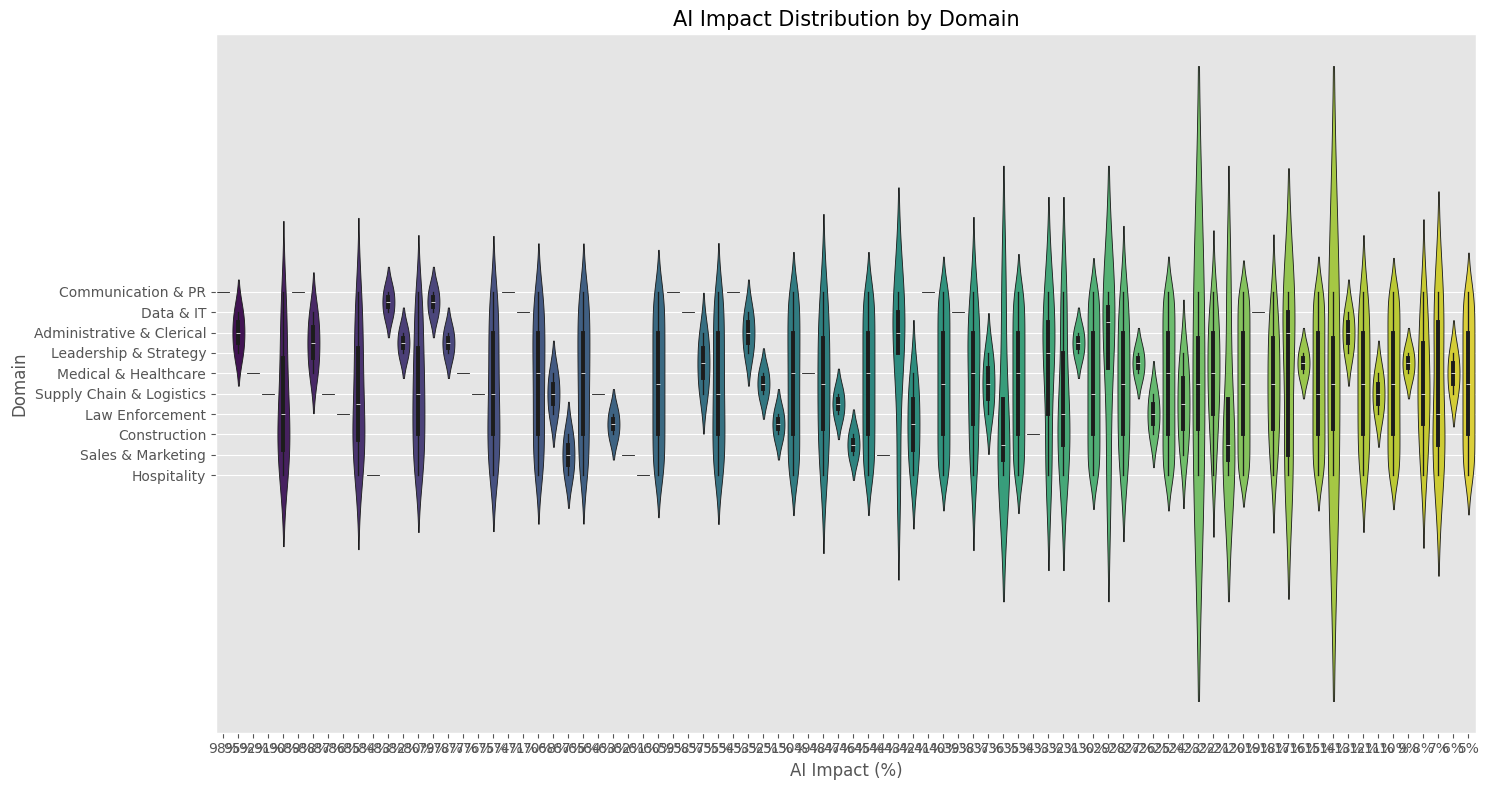

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(15, 8))
sns.violinplot(x='AI Impact', y='Domain', data=df, palette='viridis')
plt.title('AI Impact Distribution by Domain', fontsize=15)
plt.xlabel('AI Impact (%)', fontsize=12)
plt.ylabel('Domain', fontsize=12)
plt.tight_layout()
plt.show()

### VII- Order the data

We sort our data based on our "AI Impact" and organize our data in a Descending fashion.

In [ ]:
#order data

df.sort_values (by = ['AI Impact'], inplace = False, ascending = False )

#group by the domain
df.groupby('Domain')

df.head()
#export the grouped data to json
df.to_json('grouped_data.json', orient='records')
#save
df.to_csv('grouped_data.csv', index=False)
#save


# 4) Analysis and Share

### I- Brief Analysis

We conduct a brief statistical analysis using df.describe() to obtain key summary statistics such as count, mean, average, minimum, maximum, and more.

In [ ]:
#Run a quick statistical analysis to gain insights on the data
df.describe()

,Tasks,AI models,AI_Workload_Ratio
count,4706.000000,4706.000000,4699.000000
mean,400.708032,1817.678071,0.204619
std,311.564781,1086.853037,0.076547
min,1.000000,0.000000,0.036585
25%,161.000000,1085.250000,0.137262
50%,270.000000,1577.500000,0.198885
75%,608.750000,2273.000000,0.260450
max,1387.000000,5666.000000,1.000000


From this quick description we get some clues that will help us in our investigation:

- AI Impact Distribution: The "AI Impact" values vary between 0.05 and 0.98, indicating a wide range of AI influence across job titles.

- Tasks Distribution: The "Tasks" column ranges from 1 task to 1387 tasks, indicating a diverse set of job roles with varying levels of responsibility and complexity.

- AI Models Integration: The "AI models" column reveals that the average number of AI models associated with each job title is around 1817, suggesting significant adoption of AI technology. The wide standard deviation of 1086.853 indicates varying levels of AI integration across different job roles.

- AI Workload Ratio: The "AI_Workload_Ratio" has a range from 0.036 to 1.0, indicating that some job roles have minimal AI involvement (low ratios), while others rely heavily on AI (high ratios).

- Missing Data in AI_Workload_Ratio: We can see that some of the data within the "AI_Workload_Ratio" column has infinite values, we can verify this by seeing the max on that column.

- Variability: The standard deviations for "AI Impact," "Tasks," "AI models," and "AI_Workload_Ratio" suggest that there is considerable variability within each of these measures across different job titles.

- Correlations and Relationships: There might be relationships or correlations between these columns that could be explored further. For instance, a higher number of tasks might be associated with a higher number of AI models and a higher AI impact.


### II- Top 10 most impacted jobs

This code will process a DataFrame by converting percentage-based 'AI Impact' values into decimals, ranks and selects the top 10 impacted job titles, then plots a bar chart to display these impacts using Seaborn, with job titles on the y-axis and AI impact on the x-axis.

                       Job Titles  AI Impact  Tasks  AI models  \
0          Communications Manager       0.98    365       2546   
3                      Mail Clerk       0.95    193       1366   
1                  Data Collector       0.95    299       2148   
2                      Data Entry       0.95    325       2278   
4              Compliance Officer       0.92    194       1369   
5   Chief Executive Officer (CEO)       0.91    153       1135   
16                 Street Sweeper       0.90      3         82   
14          Data Entry Specialist       0.90    334       2358   
7          Chief Strategy Officer       0.90    184       1284   
10                   Mail Handler       0.90    188       1350   

    AI_Workload_Ratio                     Domain  
0            0.143362         Communication & PR  
3            0.141288      Leadership & Strategy  
1            0.139199                  Data & IT  
2            0.142669  Administrative & Clerical  
4            0.141

/tmp/ipython-input-18-3556231181.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='AI Impact', y='Job Titles', data=top_10_impacted_jobs, palette='cividis')


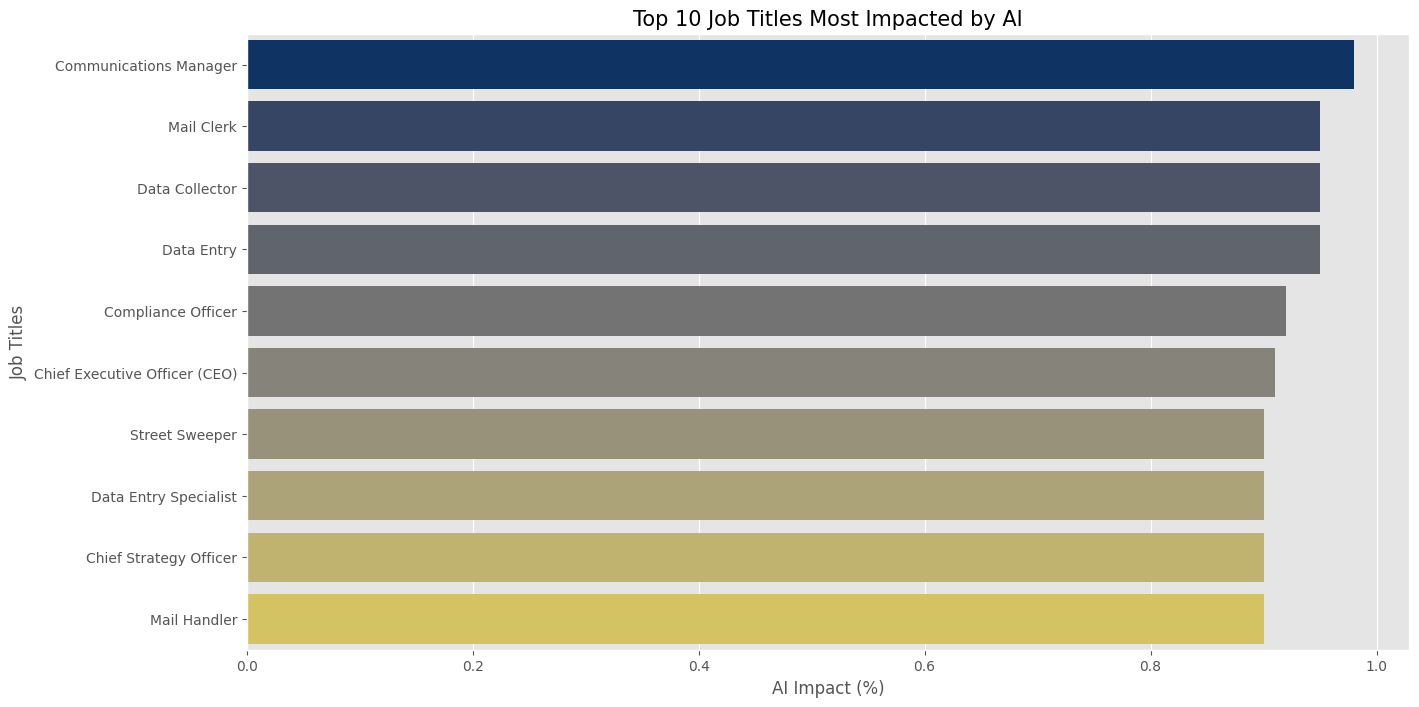

In [ ]:
# Changing the data type in the AI Impact column to Integer while removing the % sign as well

df['AI Impact'] = (df['AI Impact'].str.rstrip('%').astype('int')) / 100
top_10_impacted_jobs = df.sort_values(by='AI Impact', ascending=False).head(10)
print(top_10_impacted_jobs)

# Plotting the top 10 impacted jobs
plt.figure(figsize=(15, 8))
sns.barplot(x='AI Impact', y='Job Titles', data=top_10_impacted_jobs, palette='cividis')
plt.title('Top 10 Job Titles Most Impacted by AI', fontsize=15)
plt.xlabel('AI Impact (%)', fontsize=12)
plt.ylabel('Job Titles', fontsize=12)
plt.show()

Interpreting these findings, we observe that the role most significantly affected is that of a Communication Manager, with an AI impact of nearly 100%. This is closely trailed by Data Entry, Mail Clerk, and Data Collector roles, all with AI impacts ranging from approximately 95% to 90%. These outcomes underscore the heightened vulnerability of these positions to potential AI-driven automation in the future.

### III- Top 10 Job titles Least Impacted by AI

The follwing code will  arrange the DataFrame by decreasing 'AI Impact' values, then selects and displays the ten job titles with the lowest AI impact through a bar plot using Seaborn. The plot exhibits job titles on the y-axis and their corresponding AI impact percentages on the x-axis.





/tmp/ipython-input-19-3324093320.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='AI Impact', y='Job Titles', data=bottom_10_impacted_jobs, palette='cividis')


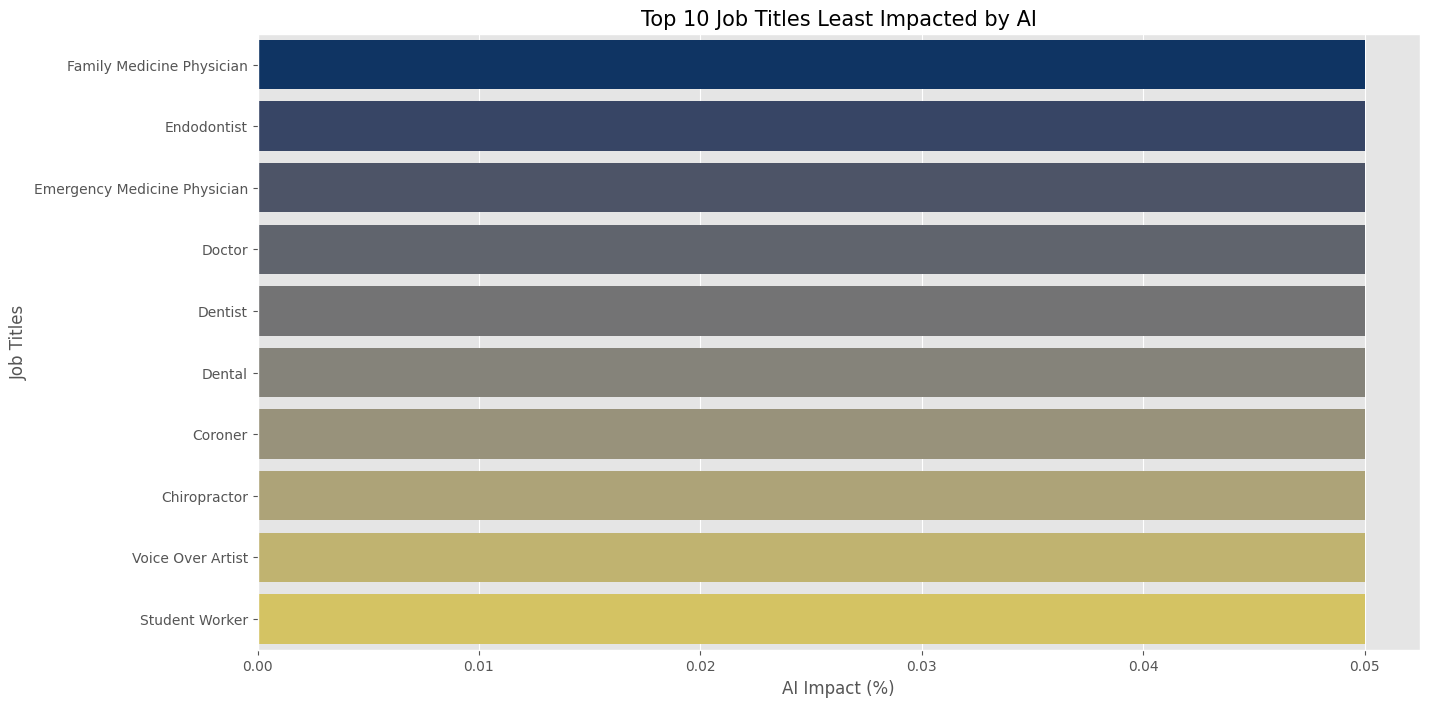

In [ ]:
# Sorting the DataFrame in descending order by AI Impact
bottom_10_impacted_jobs = df.sort_values(by='AI Impact', ascending=False).tail(10)

# Plotting the top 10 least impacted jobs
plt.figure(figsize=(15, 8))
sns.barplot(x='AI Impact', y='Job Titles', data=bottom_10_impacted_jobs, palette='cividis')
plt.title('Top 10 Job Titles Least Impacted by AI', fontsize=15)
plt.xlabel('AI Impact (%)', fontsize=12)
plt.ylabel('Job Titles', fontsize=12)
plt.show()

Drawing from these results, job titles minimally influenced, with approximately 50% impact, include roles such as Technician, Lead Pastor, Zoologist, Ranch Hand, and Veterinarian, among others. Notably, these roles are predominantly manual in nature, indicating a lower susceptibility to replacement by automation or AI in the foreseeable future.

### IV- What Domains take the most AI impact

The forthcoming code will generate a plot using Seaborn and the .stripplot() function to illustrate domains with the highest job impacts from AI, potentially leading to automation-driven replacements. This will be accomplished by utilizing the 'AI Impact' column on the x-axis and the 'Domain' column on the y-axis.

<Axes: xlabel='AI Impact', ylabel='Domain'>

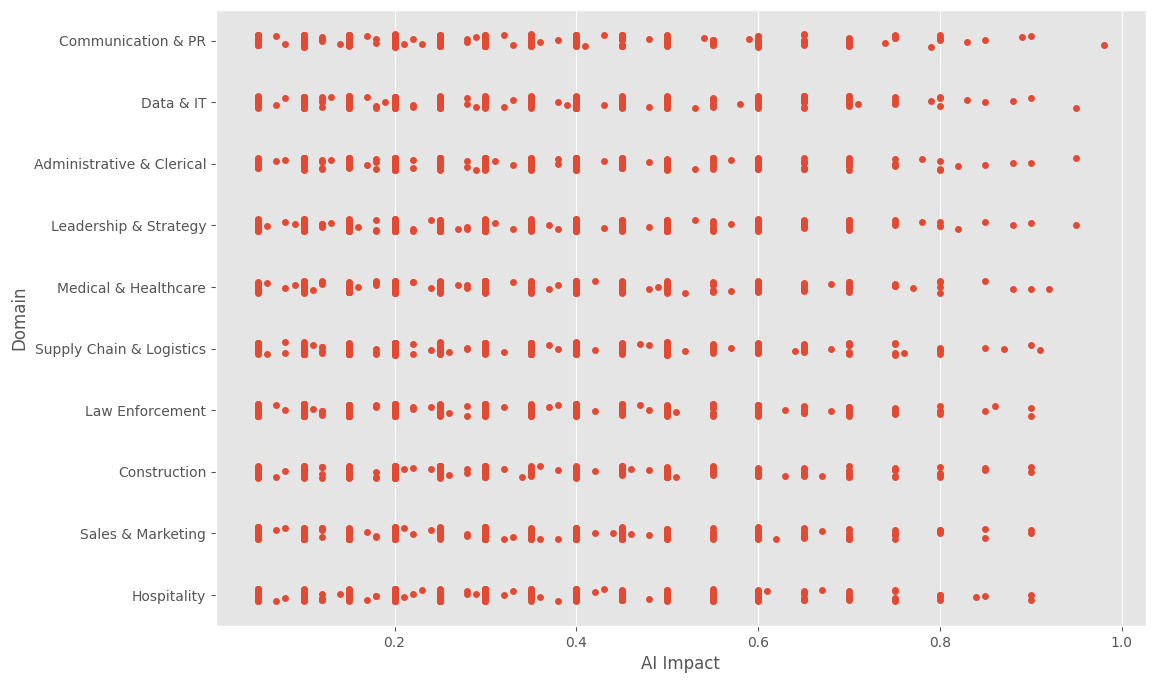

In [ ]:
#This stripplot shows us which domains have the most jobs closest to AI Impact of 100%

sns.stripplot(x="AI Impact", y="Domain", data=df)


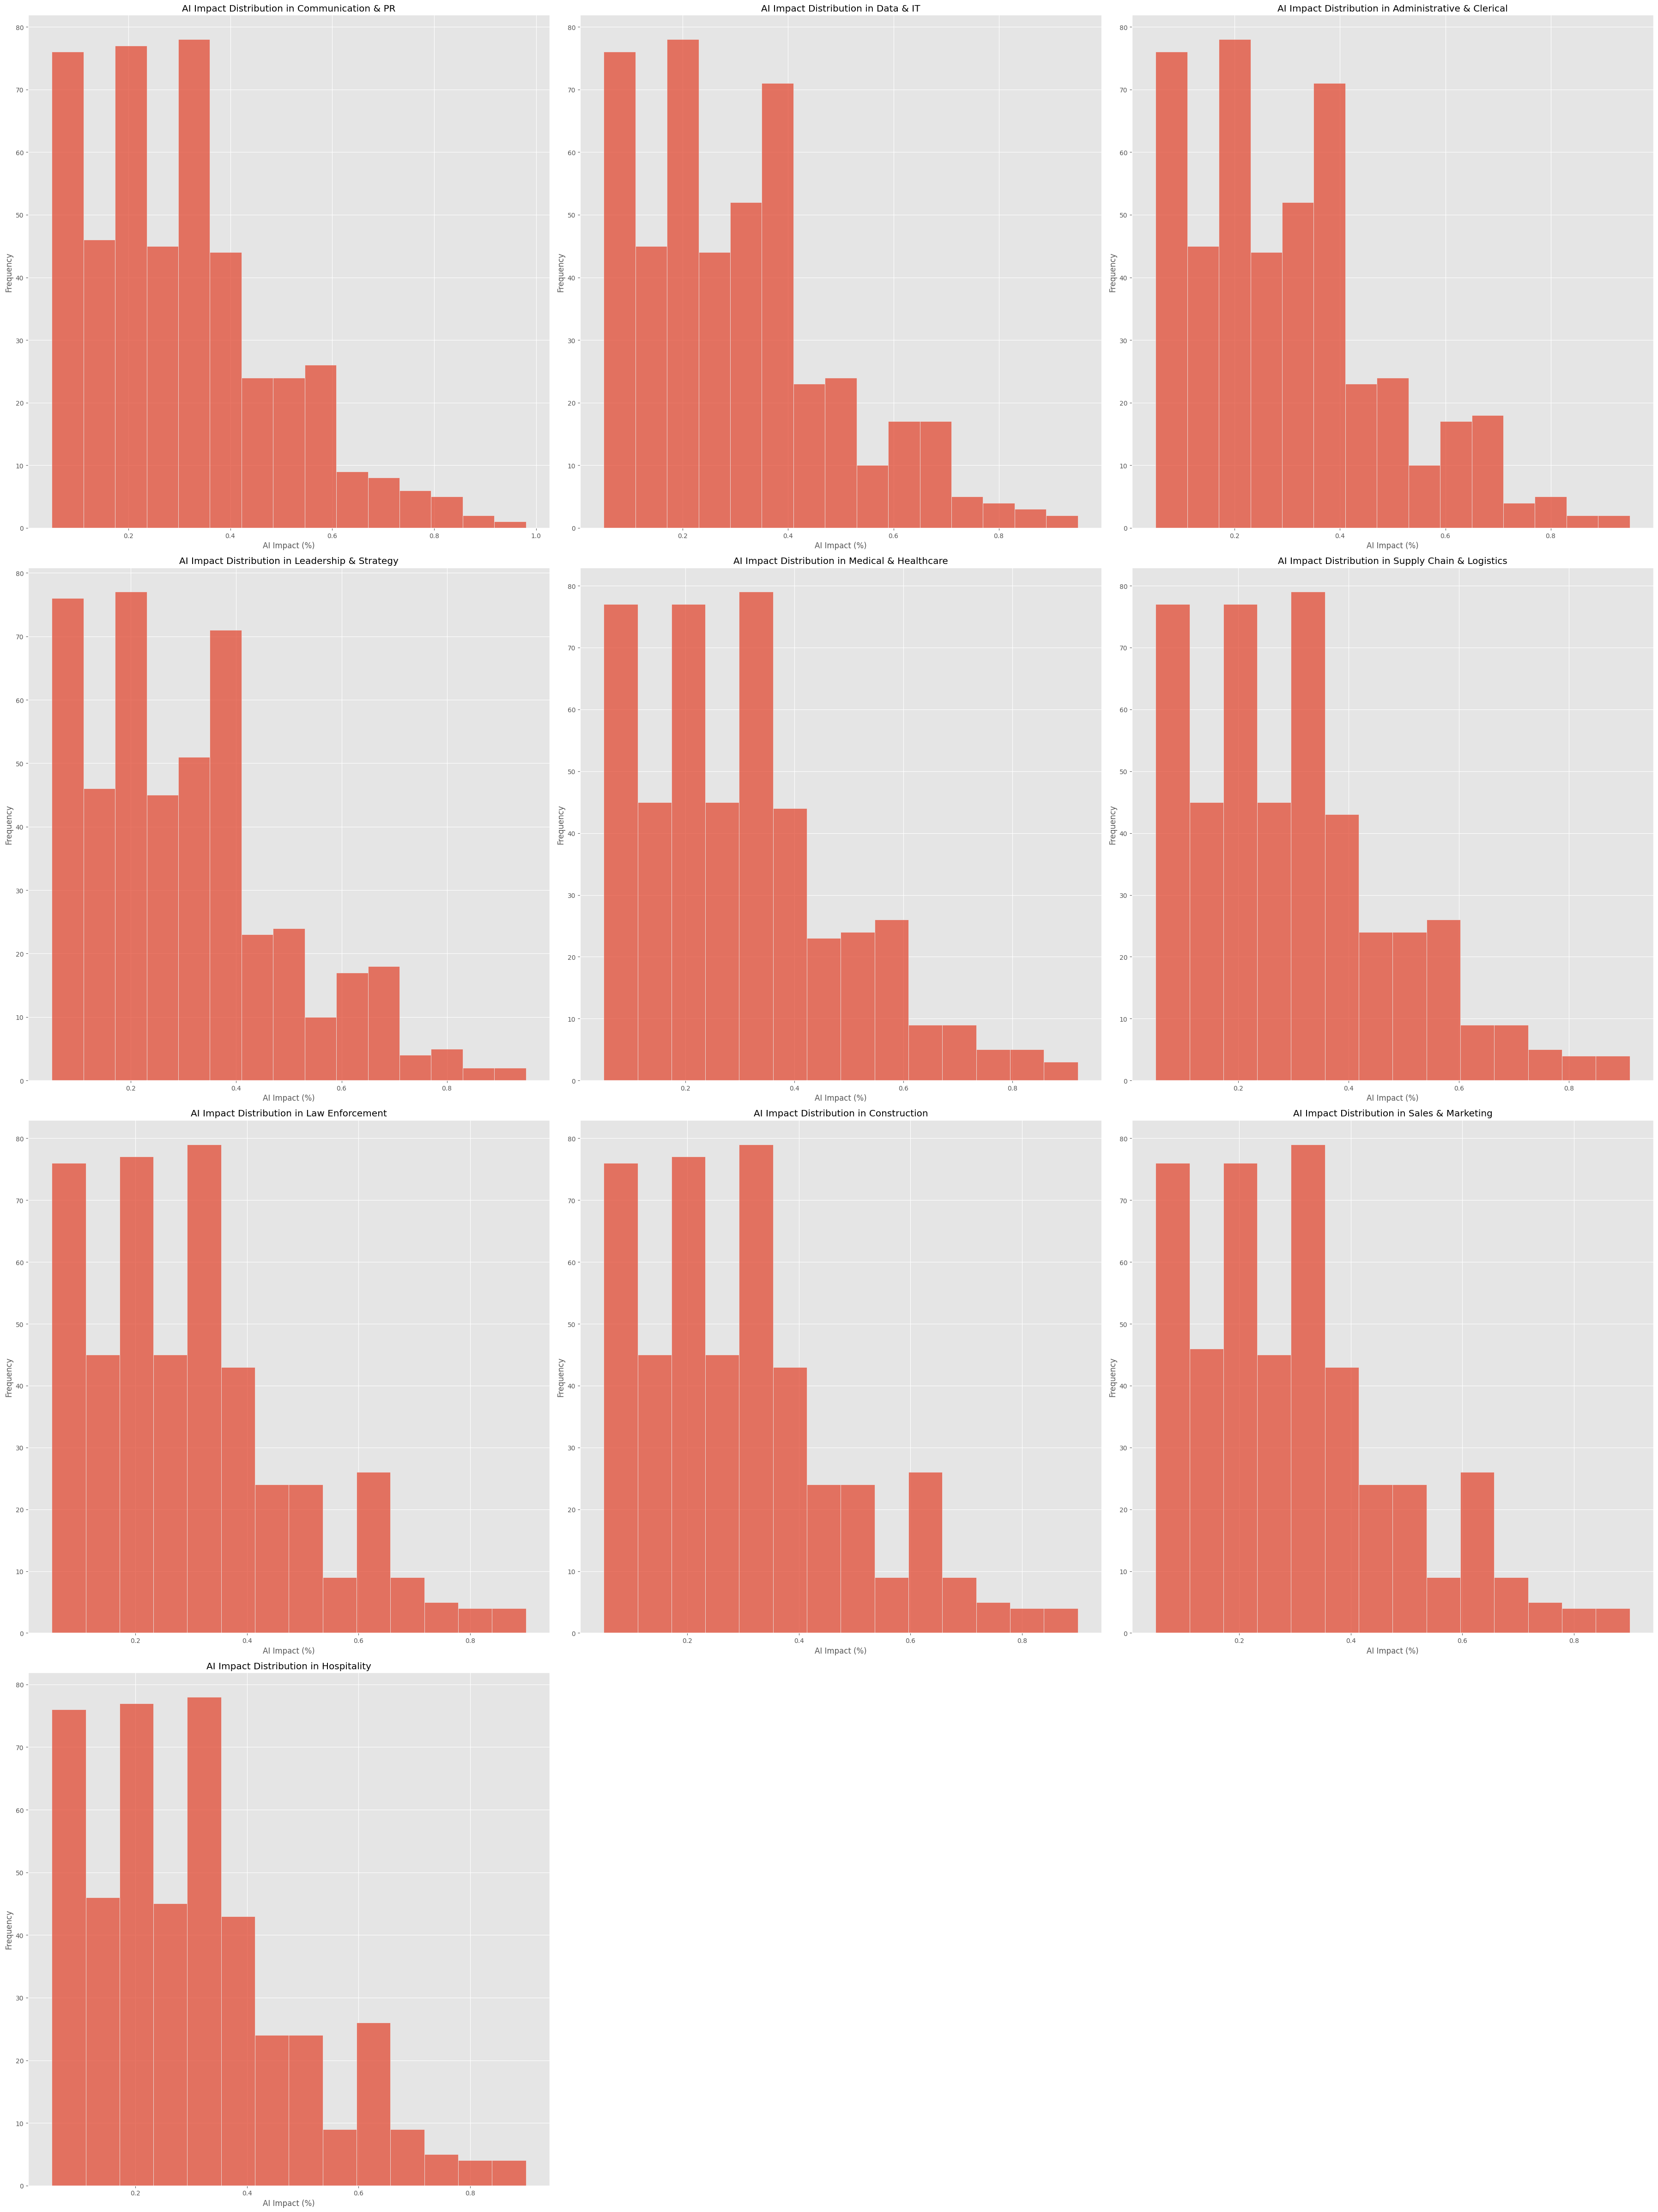

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Get unique domains
unique_domains = df['Domain'].unique()

# Set up the plot layout (optional, depending on the number of domains)
# You might want to adjust the number of columns and rows based on your needs
n_cols = 3  # Number of columns in the plot grid
n_rows = (len(unique_domains) + n_cols - 1) // n_cols # Calculate number of rows

plt.figure(figsize=(n_cols * 12, n_rows * 12)) # Adjust figure size as needed

# Iterate through domains and plot histograms
for i, domain in enumerate(unique_domains):
    plt.subplot(n_rows, n_cols, i + 1) # Create a subplot for each domain
    domain_df = df[df['Domain'] == domain]
    sns.histplot(data=domain_df, x='AI Impact', kde=False) # Use seaborn for a nice histogram with KDE
    plt.title(f'AI Impact Distribution in {domain}')
    plt.xlabel('AI Impact (%)')
    plt.ylabel('Frequency')

plt.tight_layout() # Adjust layout to prevent overlapping titles/labels
plt.show()

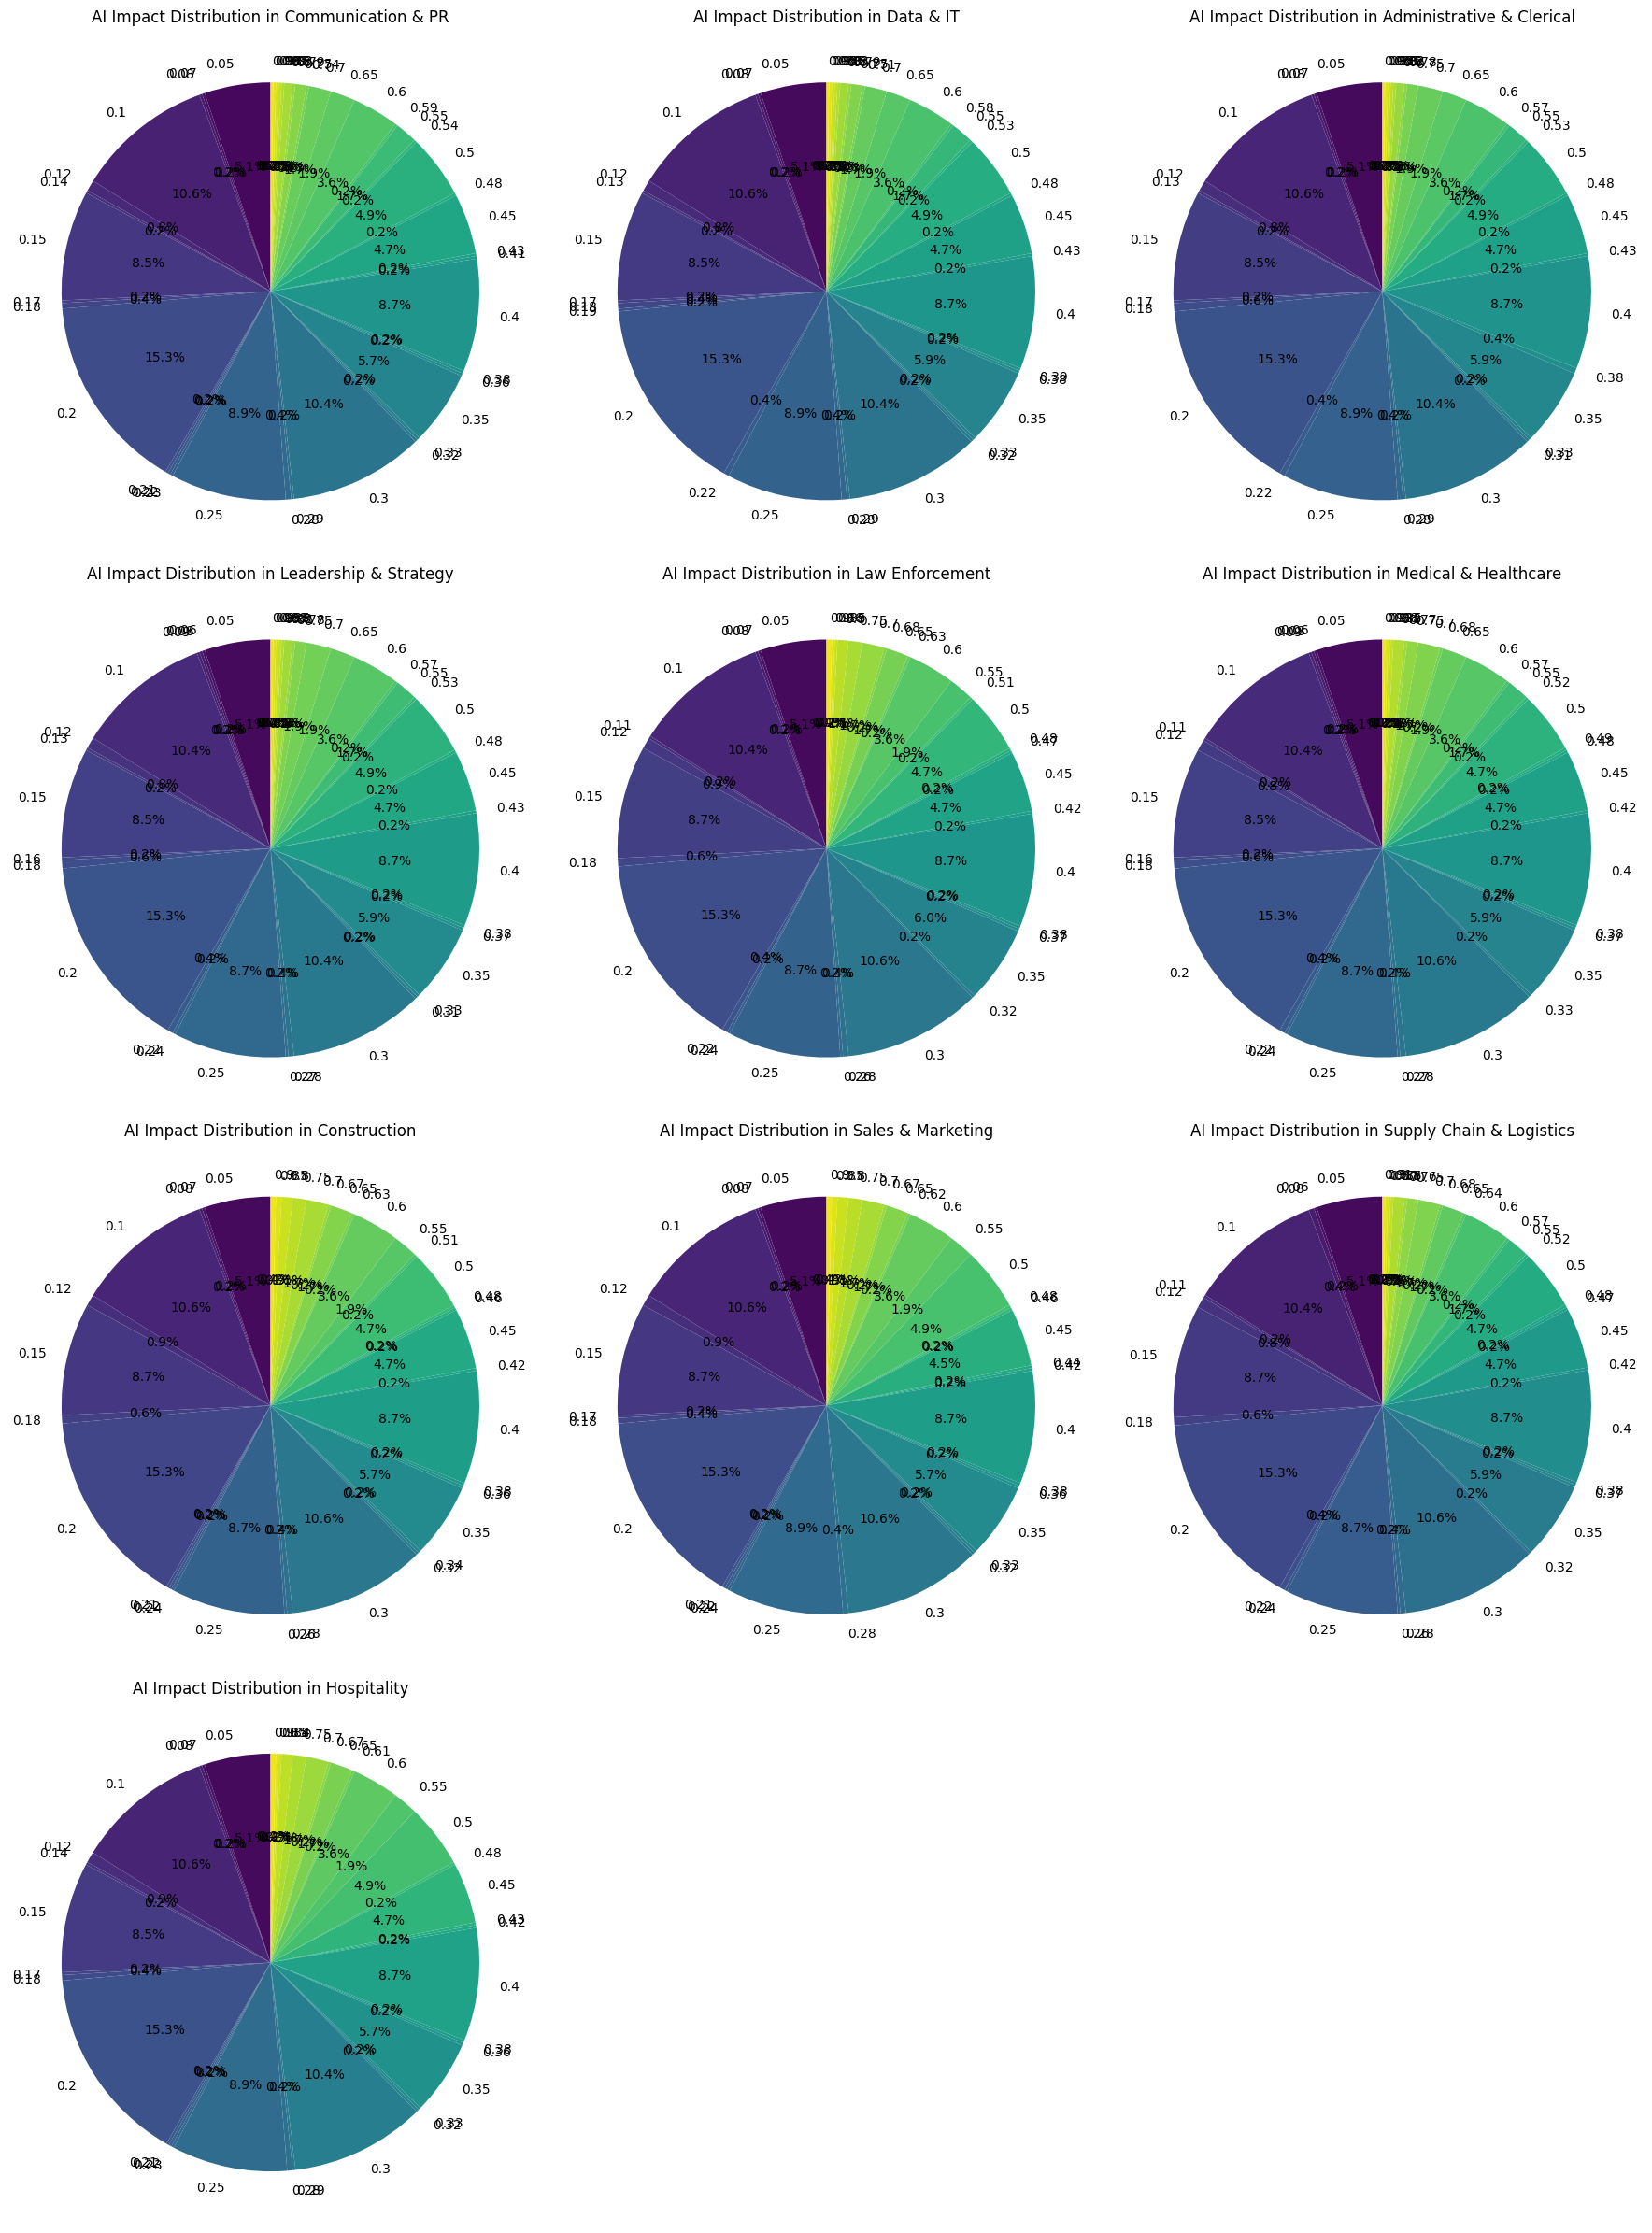

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Get unique domains
unique_domains = df['Domain'].unique()

# Calculate the count of job titles in each domain
domain_counts = df['Domain'].value_counts()

# Order the domains based on their average AI Impact for resizing
domain_avg_ai_impact = df.groupby('Domain')['AI Impact'].mean().sort_values(ascending=False)
ordered_domains = domain_avg_ai_impact.index

# Determine the number of rows and columns for subplots
n_cols = 3  # Adjust as needed
n_rows = (len(unique_domains) + n_cols - 1) // n_cols

# Set up the figure for the pie charts
fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 6, n_rows * 6))
axes = axes.flatten() # Flatten the array of axes for easy iteration

# Iterate through domains and plot pie charts
for i, domain in enumerate(ordered_domains):
    ax = axes[i]

    # Get the data for the current domain
    domain_data = df[df['Domain'] == domain]
    domain_impact_counts = domain_data['AI Impact'].value_counts().sort_index()

    # Create the pie chart
    wedges, texts, autotexts = ax.pie(domain_impact_counts,
                                      labels=domain_impact_counts.index,
                                      autopct='%1.1f%%',
                                      startangle=90,
                                      colors=sns.color_palette('viridis', len(domain_impact_counts)))

    ax.set_title(f'AI Impact Distribution in {domain}', fontsize=12)

    # Adjust the size of the pie chart based on the average AI Impact
    size_factor = domain_avg_ai_impact[domain] / domain_avg_ai_impact.max()
    #ax.set_position(ax.get_position().translated(0, 0).scaled(size_factor, size_factor))


# Remove any unused subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

In [ ]:
!pip install plotly
import plotly.express as px
import pandas as pd

# Make sure you have the plotly library installed
# If not, run: !pip install plotly

# First, we need to prepare the data for the sunburst chart.
# We need a column that represents the hierarchy: Domain -> AI Impact
# We also need a column for the value that determines the size of each section (the count of jobs)

# Group the data by Domain and AI Impact and count the occurrences
sunburst_data = df.groupby(['Domain', 'AI Impact', 'AI models', 'AI_Workload_Ratio']).size().reset_index(name='Count')


# Create a column for the parent level (the Domain) and a column for the child level (the AI Impact)
# We will also add a root node for the overall chart.
sunburst_data['All'] = 'All' # This will be the root node

# Create the sunburst chart
fig = px.sunburst(sunburst_data,
                  path=['All', 'Domain', 'AI Impact'], # Define the hierarchy
                  values='Count',                      # Define the size of each section
                  title='AI Impact Distribution by Domain')

# Display the chart
fig.show()

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Get unique domains
unique_domains = df['Domain'].unique()

# Calculate the count of job titles in each domain
domain_counts = df['Domain'].value_counts()

# Order the domains based on their average AI Impact for resizing
domain_avg_ai_impact = df.groupby('Domain')['AI Impact'].mean().sort_values(ascending=False)
ordered_domains = domain_avg_ai_impact.index

# Determine the number of rows and columns for subplots
n_cols = 3  # Adjust as needed
n_rows = (len(unique_domains) + n_cols - 1) // n_cols

# Set up the figure for the pie charts
fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 6, n_rows * 6))
axes = axes.flatten() # Flatten the array of axes for easy iteration

# Iterate through domains and plot pie charts
for i, domain in enumerate(ordered_domains):
    ax = axes[i]

    # Get the data for the current domain
    domain_data = df[df['Domain'] == domain]
    domain_impact_counts = domain_data['AI Impact'].value_counts().sort_index()

    # Create the pie chart
    wedges, texts, autotexts = ax.pie(domain_impact_counts,
                                      labels=domain_impact_counts.index,
                                      autopct='%1.1f%%',
                                      startangle=90,
                                      colors=sns.color_palette('viridis', len(domain_impact_counts)))

    ax.set_title(f'AI Impact Distribution in {domain}', fontsize=12)

    # Adjust the size and position of the pie chart based on the average AI Impact
    size_factor = domain_avg_ai_impact[domain] / domain_avg_ai_impact.max()
    original_pos = ax.get_position()

    # Access the bounds using get_points() or by indexing
    x0, y0 = original_pos.get_points()[0]  # Bottom-left corner
    x1, y1 = original_pos.get_points()[1]  # Top-right corner

    original_width = x1 - x0
    original_height = y1 - y0

    new_width = original_width * size_factor
    new_height = original_height * size_factor

    # Calculate the new bottom-left corner to center the scaled pie chart
    new_x0 = x0 + (original_width - new_width) / 2
    new_y0 = y0 + (original_height - new_height) / 2

    # Set the new position using a list of [x0, y0, width, height]
    ax.set_position([new_x0, new_y0, new_width, new_height])


# Remove any unused subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

In [ ]:
# prompt: Using dataframe domain_df: for all the unique domains, draw a A pie chart instead of histogram with proper annotations and color coding(for each domain) to make it more viewr friendly

import altair as alt

# Calculate the count of each domain
domain_counts = domain_df['Domain'].value_counts().reset_index()
domain_counts.columns = ['Domain', 'Count']

# Create the pie chart
chart = alt.Chart(domain_counts).mark_arc(outerRadius=120).encode(
    theta=alt.Theta(field="Count", type="quantitative"),
    color=alt.Color(field="Domain", type="nominal"),
    order=alt.Order(field="Count", sort="descending"),
    tooltip=['Domain', 'Count']
).properties(
    title='Distribution of Domains'
)

# Add text labels
text = alt.Chart(domain_counts).mark_text(radius=140).encode(
    text=alt.Text(field="Count", type="quantitative"),
    order=alt.Order(field="Count", sort="descending"),
    color=alt.value("black")  # Set the color of the labels to black
)

# Combine the pie chart and the text labels
chart + text

The outcomes indicate that domains such as "Communication and PR," "Data and IT," and "Administrative and Clerical" have jobs that are most proximate to complete AI automation. However, there is an overarching trend wherein a substantial portion of jobs across all domains exhibit job impact scores exceeding 80%, suggesting their potential for future automation.

### V- Studying correlation among numerical values

We utilize the .corr() function to compute correlations among numerical values within our dataset, thereby identifying the strongest correlations. Additionally, we extend our analysis to include non-numerical columns by applying the .factorize() function, which assigns temporary numerical counterparts to our categorical values.

In [ ]:
#We calculate the correlation using the Pearson Correlation
df.corr(method='pearson')

In [ ]:
#pull the pairs with highest correlation in our data
#Give integer numbers to all of our string values
correlation_mat = df.apply(lambda x: x.factorize()[0]).corr()

#We use unstack to ive a wide format
corr_pairs = correlation_mat.unstack()

# we sort our values using the "quicksort" method, which is great for large datasets

sorted_pairs = corr_pairs.sort_values(kind="quicksort")

strong_correlation = sorted_pairs[abs(sorted_pairs) > 0.5]

print(strong_correlation)

Based on these correlation results, we can observe the following aspects:

- Job Titles exhibit notably strong correlations with AI Impact (0.963), AI_Workload_Ratio (0.958), and AI models (0.696), indicating a close relationship between job titles and these factors.

- AI Impact also demonstrates strong correlations with AI models (0.678) and AI_Workload_Ratio (0.923), suggesting a significant link between the impact of AI and these variables.

- Tasks and AI models have a relatively high correlation (0.558), potentially implying that the complexity of tasks is connected to the implementation of AI models.

These correlations suggest intricate relationships between job titles, AI impact, workload ratios, tasks, and AI models within the dataset.

### VI- Represent visually our correlations

These three codes will generate scatter plots with regression lines using the Seaborn library:

- The first code will produce a scatter plot of 'Tasks' against 'AI models' from the DataFrame 'df'. The scatter points will be in red, and the regression line will be in blue.

- The second code will create a scatter plot of 'Tasks' against 'AI_Workload_Ratio' from the DataFrame 'df'. The scatter points will be in green, and the regression line will be in blue.

- The third code will result in a scatter plot of 'AI models' against 'AI_Workload_Ratio' from the DataFrame 'df'. The scatter points will be in orange, and the regression line will be in blue.

Each plot will provide a visual representation of the relationships between the specified pairs of variables, along with a fitted regression line to depict the trend in the data.



In [ ]:
# Possible correlation between Tasks and AI Models

sns.regplot (x= 'Tasks', y= 'AI models', data = df,scatter_kws = {"color":"red"}, line_kws = {"color":"Blue"})

In [ ]:
#Possible Correlation between AI_Workload_Radio and Tasks

sns.regplot (x= 'Tasks', y= 'AI_Workload_Ratio', data = df,scatter_kws = {"color":"green"}, line_kws = {"color":"blue"})

In [ ]:
#Possible correlation between AI Models and AI_Workload_Ratio

sns.regplot (x= 'AI models', y= 'AI_Workload_Ratio', data = df,scatter_kws = {"color":"orange"}, line_kws = {"color":"blue"})

### VII- Matrix correlation

We aim to visualize correlation patterns through a correlation matrix:

Initially, we construct a straightforward matrix for numerical features, displaying solely those columns with numeric data types, and render the comparison feasible via the .heatmap() function. We employ the "Pearson" method, which is the default approach for correlations.

Subsequently, we generate an additional matrix that encompasses non-numerical values, briefly converting them into numerical counterparts using the .factorize() function.

In [ ]:
#We represent correlation using a Heatmap

correlation_matrix = df.corr(method='pearson')

sns.heatmap(correlation_matrix, annot = True)
plt.title('Correlation Matrix of Numeric Features')
plt.xlabel('AI Features')
plt.ylabel('AI Features')
plt.show()

In [ ]:
#We assign numerical values to the String values

correlation_matrix = df.apply(lambda x: x.factorize()[0]).corr(method='pearson')

#We Create a matrix that includes this new values and examine that correlation

sns.heatmap(correlation_matrix, annot = True)

plt.title("Correlation Matrix for Dataset")

plt.xlabel("AI features")

plt.ylabel("AI features")

plt.show()

### VIII- Tasks Vs AI Models scatterplot based on Domain

Lastly, our intention is to delve into the correlation between 'Tasks' and 'AI models', with 'Domains' represented as the hue. This scatter plot aims to provide a swift overview of the positioning of various domains within this relationship.

In [ ]:
#We create a scatterplot that shows the Relationship between Tasks and AI Models by Domain

plt.figure(figsize=(18, 12))
sns.scatterplot(data=df, x='Tasks', y='AI models', hue='Domain')
plt.title('Correlation of Tasks and AI Models in Different Domains', fontsize=15)
plt.xlabel('Tasks', fontsize=15)
plt.ylabel('AI Models', fontsize=15)
plt.legend(title='Domain', bbox_to_anchor=(1, 1), loc='upper left')
plt.tight_layout()
plt.show()

The majority of jobs typically entail a relatively modest number of tasks (ranging from 0 to 400), indicating that a relatively small number of AI models (ranging from 0 to 2500) would be necessary to potentially replace human labor and fulfill the requirements of those jobs.

# 5) Act

Based on our investigation, it is evident that AI is exerting its influence across all societal job domains, albeit to varying extents. Particularly, its impact is more pronounced in job areas that rely less on manual tasks and are more intertwined with computer-based functions. This highlights the widespread nature of AI's reach and its concentrated effect on roles closely tied to computational processes.

The inevitable integration of AI into our daily work tasks should not be perceived solely as a threat to our jobs, but rather as an opportunity for growth. Liberated from mundane and routine tasks, we can channel our efforts into more profound responsibilities that demand extended development time. Endeavors such as these projects and reports can serve as invaluable learning experiences for companies, enabling proactive integration with AI, which might lead to the displacement of certain roles but also pave the way for novel positions that align with this evolving technology.
